# 02. Crack Defect Detection — MVTec AD Tile

本 notebook 針對 MVTec AD `tile` 類別中的 `crack` 瑕疵建立一個可解釋的傳統影像處理流程。

本節目標分成兩層：

- **主要目標：image-level detection**  
  判斷輸入影像是否存在 crack，輸出 `Yes / No`。

- **次要目標：segmentation-like localization**  
  產生 crack candidate mask，標示判斷依據的位置。這個 mask 不是完整 segmentation，但可作為 defect localization 的可視化證據。

本 notebook 保留探索過程中的關鍵失敗案例，重點不只是得到結果，而是釐清每個方法的假設、限制，以及最後為什麼選擇 black-hat morphology 作為較合理的 traditional baseline。

In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 控制 notebook 內圖片大小，避免輸出過大
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100
plt.rcParams["font.size"] = 10

## Step 1. Paths and Data Loading

本節使用 `defect/crack` 作為待偵測影像，並使用 `ground_truth/crack` 驗證 localization 是否大致落在真實裂縫區域。`good` 樣本只用於灰階分布比較，幫助判斷 crack 與正常紋理是否能靠 intensity 分離。

In [2]:
PROJECT_DIR = Path("..")

DATA_DIR = PROJECT_DIR / "data"
GOOD_DIR = DATA_DIR / "good"
DEFECT_DIR = DATA_DIR / "defect"
GT_DIR = DATA_DIR / "ground_truth"

CRACK_DIR = DEFECT_DIR / "crack"
CRACK_GT_DIR = GT_DIR / "crack"

CRACK_IMAGE_PATH = CRACK_DIR / "000.png"
CRACK_GT_PATH = CRACK_GT_DIR / "000_mask.png"

GOOD_IMAGE_PATHS = sorted(GOOD_DIR.glob("*.png"))
if len(GOOD_IMAGE_PATHS) == 0:
    raise FileNotFoundError(f"No good images found in: {GOOD_DIR}")

GOOD_IMAGE_PATH = GOOD_IMAGE_PATHS[0]

print("Crack image:", CRACK_IMAGE_PATH)
print("Good image:", GOOD_IMAGE_PATH)
print("Ground truth:", CRACK_GT_PATH)

Crack image: ..\data\defect\crack\000.png
Good image: ..\data\good\000.png
Ground truth: ..\data\ground_truth\crack\000_mask.png


## Step 2. Utility Functions

共用函式集中定義，避免後續每個實驗重複撰寫讀圖、overlay、component analysis 與 metric 計算。後續各 section 只保留與該實驗直接相關的程式碼。

In [3]:
def read_bgr_image(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Image not found or cannot be read: {image_path}")
    return image


def read_gray_image(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found or cannot be read: {image_path}")
    return image


def get_gt_path_for_defect(defect_image_path: Path, gt_dir: Path) -> Path:
    return gt_dir / f"{defect_image_path.stem}_mask.png"


def remove_small_components(binary_mask: np.ndarray, min_area: int = 40) -> np.ndarray:
    binary = (binary_mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    cleaned = np.zeros_like(binary, dtype=np.uint8)
    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == label_id] = 255

    return cleaned


def overlay_mask_on_image(image_rgb: np.ndarray, mask: np.ndarray | None, alpha: float = 0.45) -> np.ndarray:
    overlay = image_rgb.copy()

    if mask is None:
        return overlay

    mask = np.asarray(mask)

    if mask.shape[:2] != image_rgb.shape[:2]:
        mask = cv2.resize(
            mask,
            (image_rgb.shape[1], image_rgb.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    mask_bool = mask > 0
    if not np.any(mask_bool):
        return overlay

    red_layer = np.zeros_like(image_rgb, dtype=np.uint8)
    red_layer[:, :, 0] = 255

    overlay[mask_bool] = (
        image_rgb[mask_bool].astype(np.float32) * (1 - alpha)
        + red_layer[mask_bool].astype(np.float32) * alpha
    ).astype(np.uint8)

    return overlay


def compute_mask_metrics(pred_mask: np.ndarray, gt_mask: np.ndarray) -> dict:
    pred = pred_mask > 0
    gt = gt_mask > 0

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    pred_area = pred.sum()
    gt_area = gt.sum()

    return {
        "iou": intersection / union if union > 0 else 0.0,
        "precision": intersection / pred_area if pred_area > 0 else 0.0,
        "recall": intersection / gt_area if gt_area > 0 else 0.0,
    }


def extract_component_features(binary_mask: np.ndarray) -> tuple[np.ndarray, list[dict]]:
    binary = (binary_mask > 0).astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    image_long_side = max(binary.shape)
    records = []

    for label_id in range(1, num_labels):
        x = stats[label_id, cv2.CC_STAT_LEFT]
        y = stats[label_id, cv2.CC_STAT_TOP]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]
        area = stats[label_id, cv2.CC_STAT_AREA]

        bbox_area = w * h
        long_side = max(w, h)
        short_side = max(1, min(w, h))

        records.append({
            "label_id": label_id,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "area": area,
            "long_side_ratio": long_side / image_long_side,
            "aspect_ratio": long_side / short_side,
            "extent": area / bbox_area if bbox_area > 0 else 0.0,
            "centroid": centroids[label_id],
        })

    return labels, records


def build_component_mask(labels: np.ndarray, selected_components: list[dict]) -> np.ndarray:
    mask = np.zeros_like(labels, dtype=np.uint8)
    for record in selected_components:
        mask[labels == record["label_id"]] = 255
    return mask


def show_image_grid(images, titles, ncols=4, figsize=(12, 6), suptitle=None, cmap_list=None):
    n = len(images)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    if cmap_list is None:
        cmap_list = [None] * n

    for idx, ax in enumerate(axes):
        if idx < n:
            ax.imshow(images[idx], cmap=cmap_list[idx])
            ax.set_title(titles[idx], fontsize=9)
        ax.axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontsize=12)

    plt.tight_layout()
    plt.show()

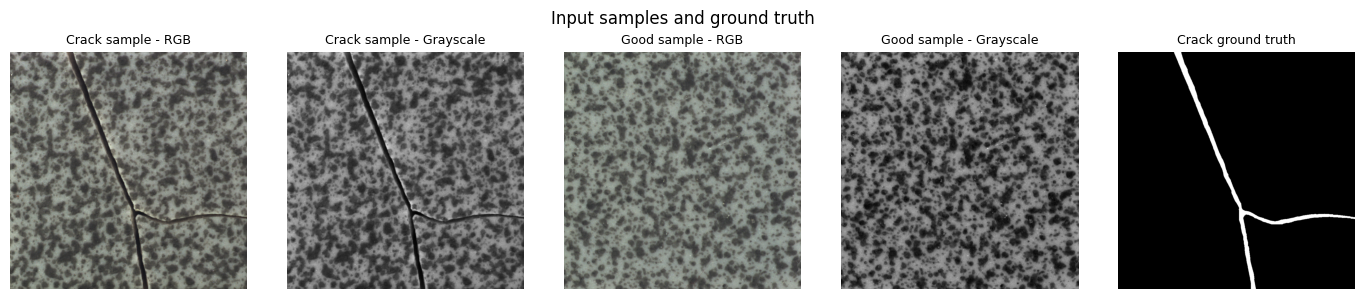

In [4]:
crack_bgr = read_bgr_image(CRACK_IMAGE_PATH)
crack_rgb = cv2.cvtColor(crack_bgr, cv2.COLOR_BGR2RGB)
crack_gray = cv2.cvtColor(crack_bgr, cv2.COLOR_BGR2GRAY)

good_bgr = read_bgr_image(GOOD_IMAGE_PATH)
good_rgb = cv2.cvtColor(good_bgr, cv2.COLOR_BGR2RGB)
good_gray = cv2.cvtColor(good_bgr, cv2.COLOR_BGR2GRAY)

crack_gt = read_gray_image(CRACK_GT_PATH)
gt_binary = (crack_gt > 0).astype(np.uint8) * 255

show_image_grid(
    images=[crack_rgb, crack_gray, good_rgb, good_gray, gt_binary],
    titles=[
        "Crack sample - RGB",
        "Crack sample - Grayscale",
        "Good sample - RGB",
        "Good sample - Grayscale",
        "Crack ground truth"
    ],
    ncols=5,
    figsize=(14, 3),
    suptitle="Input samples and ground truth",
    cmap_list=[None, "gray", None, "gray", "gray"]
)

### Observation

crack 樣本中的裂縫多半呈現暗色、細長且連續的結構；good 樣本則有大量自然斑點紋理。這代表「暗色」是可用線索，但不是充分條件，因為正常 tile texture 也包含許多暗色區域。

## Step 3. Crack vs Good Intensity Distribution

本節比較 crack sample 與 good sample 的灰階分布。目的不是直接決定閾值，而是確認固定 threshold 是否有機會穩定分離 crack 與正常紋理。

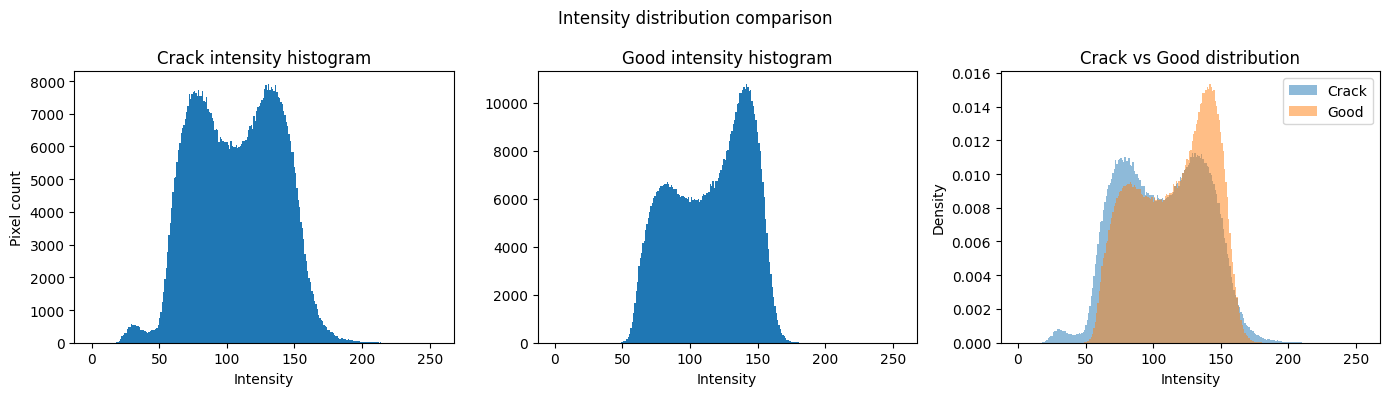

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(crack_gray.ravel(), bins=256, range=(0, 255))
axes[0].set_title("Crack intensity histogram")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixel count")

axes[1].hist(good_gray.ravel(), bins=256, range=(0, 255))
axes[1].set_title("Good intensity histogram")
axes[1].set_xlabel("Intensity")

axes[2].hist(crack_gray.ravel(), bins=256, range=(0, 255), density=True, alpha=0.5, label="Crack")
axes[2].hist(good_gray.ravel(), bins=256, range=(0, 255), density=True, alpha=0.5, label="Good")
axes[2].set_title("Crack vs Good distribution")
axes[2].set_xlabel("Intensity")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.suptitle("Intensity distribution comparison")
plt.tight_layout()
plt.show()

### Observation

crack 與 good 的分布確實不同，但兩者在暗色區域仍有重疊。這表示 thresholding 可以作為 baseline，但不太可能只靠單一灰階值穩定區分 crack 與正常紋理。

## Step 4. Manual Threshold Baseline

本節先測試固定閾值。由於 crack 多半是暗色結構，因此使用 `THRESH_BINARY_INV`，讓低於閾值的區域成為 white candidate。這一步用來觀察「單靠絕對灰階值」的能力與限制。

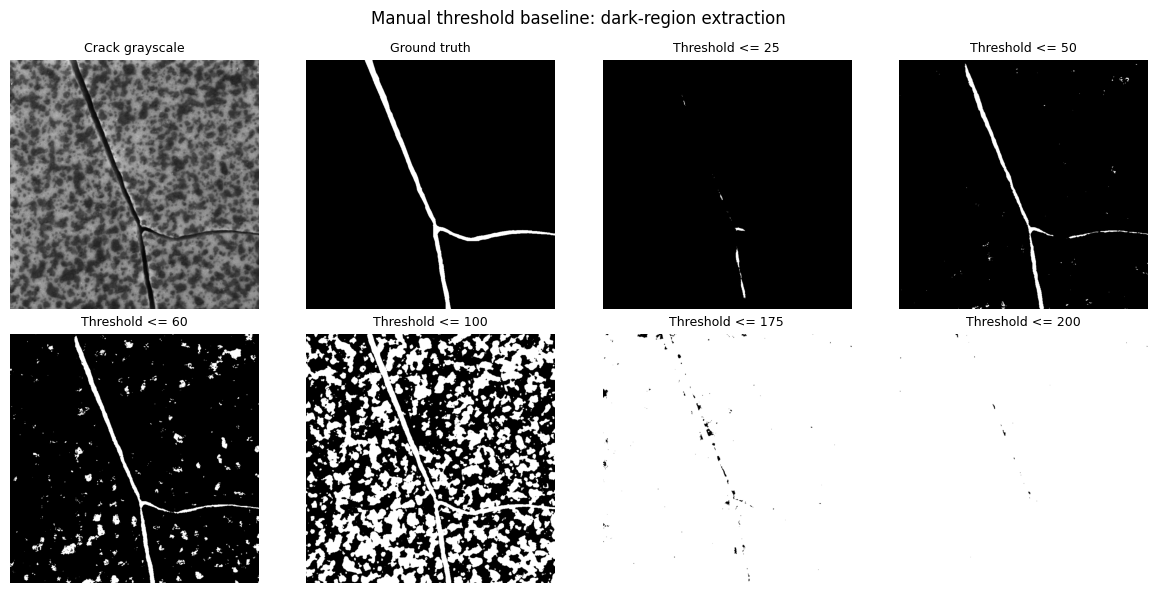

In [6]:
threshold_values = [25, 50, 60, 100, 175, 200]
manual_threshold_masks = {}

for threshold in threshold_values:
    _, mask = cv2.threshold(crack_gray, threshold, 255, cv2.THRESH_BINARY_INV)
    manual_threshold_masks[threshold] = mask

images = [crack_gray, gt_binary] + [manual_threshold_masks[t] for t in threshold_values]
titles = ["Crack grayscale", "Ground truth"] + [f"Threshold <= {t}" for t in threshold_values]
cmaps = ["gray"] * len(images)

show_image_grid(
    images=images,
    titles=titles,
    ncols=4,
    figsize=(12, 6),
    suptitle="Manual threshold baseline: dark-region extraction",
    cmap_list=cmaps
)

### Observation

`T=50` 背景雜訊少，但可能漏掉較淡的裂縫；`T=60` 保留較多裂縫，但紋理誤檢增加；`T=100` 以上幾乎把大量 tile texture 一起抓出來。這裡先保留 `T=50` 和 `T=60` 作為後續候選，其餘只作為對照。

### Adaptive Thresholding

目標：測試局部 threshold 是否能比固定 threshold 更完整保留 crack。  
觀察重點：是否同時放大 tile texture。

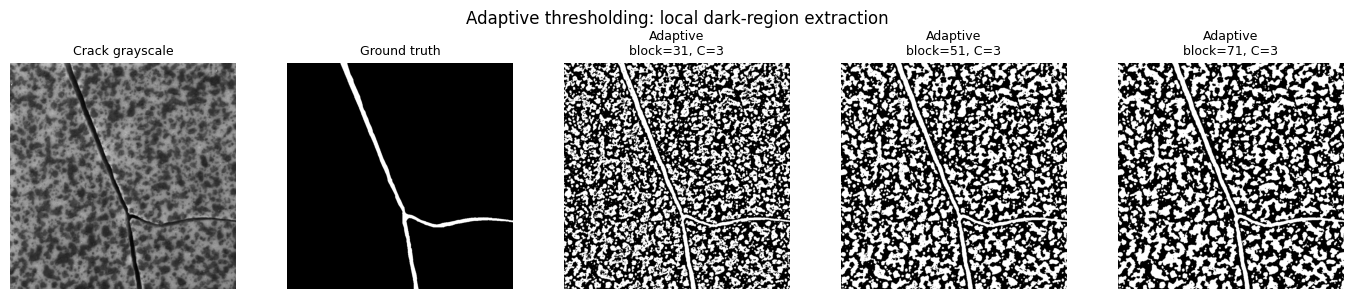

In [7]:
adaptive_params = [
    {"block_size": 31, "C": 3},
    {"block_size": 51, "C": 3},
    {"block_size": 71, "C": 3},
]

adaptive_masks = []

for params in adaptive_params:
    mask = cv2.adaptiveThreshold(
        crack_gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        params["block_size"],
        params["C"]
    )
    adaptive_masks.append(mask)

images = [crack_gray, gt_binary] + adaptive_masks
titles = ["Crack grayscale", "Ground truth"] + [
    f"Adaptive\nblock={p['block_size']}, C={p['C']}" for p in adaptive_params
]

show_image_grid(
    images=images,
    titles=titles,
    ncols=5,
    figsize=(14, 3),
    suptitle="Adaptive thresholding: local dark-region extraction",
    cmap_list=["gray"] * len(images)
)

### Observation

Adaptive thresholding 能保留 crack，但也大量放大背景紋理。這個方向對 crack 完整度有幫助，但 candidate mask 太髒，不適合作為主要 pipeline。

## Step 5. Edge-based Attempts

本節測試 edge-based 方法是否能改善 threshold 的限制。重點不是直接產生 final mask，而是判斷哪些中間結果值得後處理。

### Step 5A. Canny on Manual Threshold Masks

目標：觀察 Canny 套用在 binary threshold mask 上的結果。  
注意：這不是標準灰階 Canny，而是提取 threshold candidate 的邊界。

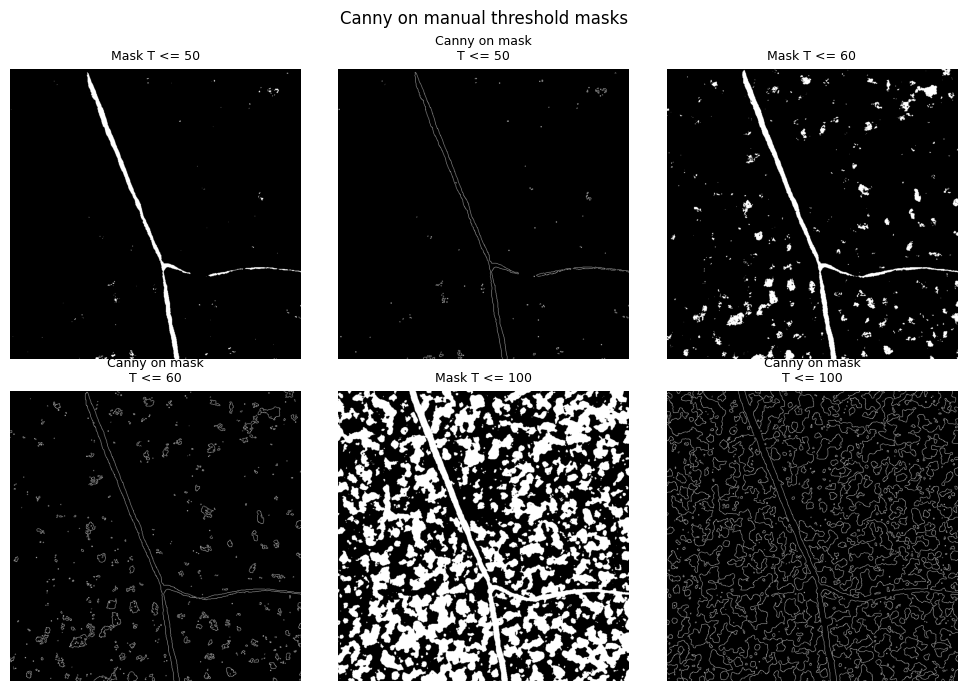

In [8]:
selected_thresholds = [50, 60, 100]
manual_canny_edges = {}

for threshold in selected_thresholds:
    mask = manual_threshold_masks[threshold]
    edges = cv2.Canny(mask, threshold1=50, threshold2=150)
    manual_canny_edges[threshold] = edges

images, titles = [], []
for threshold in selected_thresholds:
    images.extend([manual_threshold_masks[threshold], manual_canny_edges[threshold]])
    titles.extend([f"Mask T <= {threshold}", f"Canny on mask\nT <= {threshold}"])

show_image_grid(
    images=images,
    titles=titles,
    ncols=3,
    figsize=(10, 7),
    suptitle="Canny on manual threshold masks",
    cmap_list=["gray"] * len(images)
)

### Observation

Canny on binary mask 只會忠實描出候選區域邊界。若 threshold mask 太髒，Canny 結果也會變髒；若 threshold 已漏掉 crack，Canny 也無法補回。

### Step 5B. Canny on Adaptive Threshold Masks

目標：確認 adaptive mask 是否值得接 Canny。  
觀察重點：是否只是把已經過多的背景紋理轉成更多碎邊界。

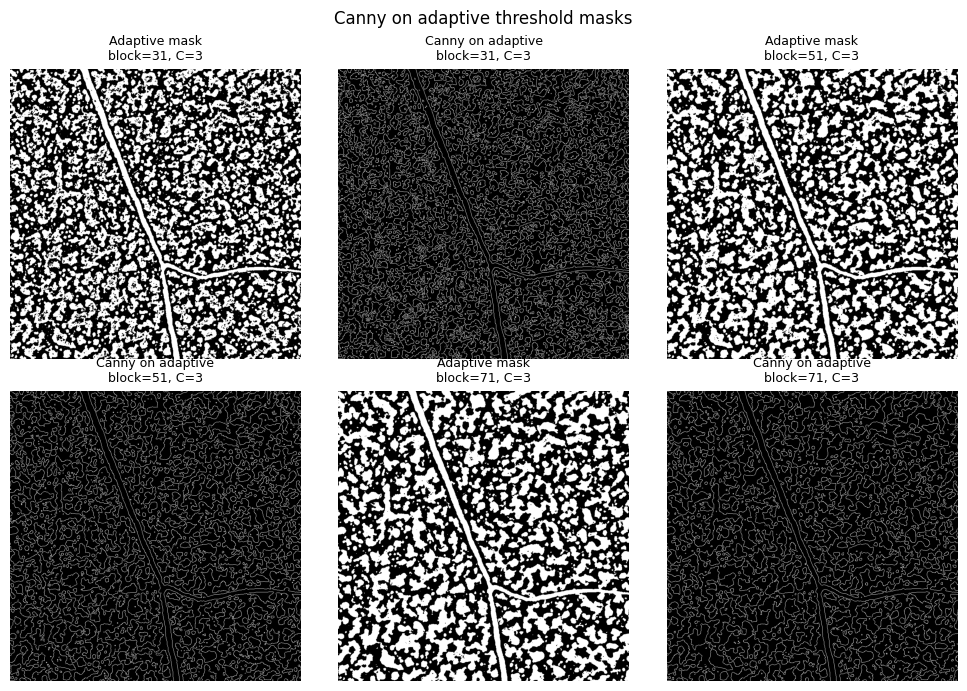

In [9]:
adaptive_canny_edges = [cv2.Canny(mask, 50, 150) for mask in adaptive_masks]

images, titles = [], []
for params, mask, edges in zip(adaptive_params, adaptive_masks, adaptive_canny_edges):
    label = f"block={params['block_size']}, C={params['C']}"
    images.extend([mask, edges])
    titles.extend([f"Adaptive mask\n{label}", f"Canny on adaptive\n{label}"])

show_image_grid(
    images=images,
    titles=titles,
    ncols=3,
    figsize=(10, 7),
    suptitle="Canny on adaptive threshold masks",
    cmap_list=["gray"] * len(images)
)

### Observation

Adaptive mask 本身已經包含大量背景紋理，因此 Canny 後只會產生更多 texture boundaries。這條路線不繼續作為主要方向。

### Step 5C. Canny on Grayscale Image

目標：使用 Canny 較標準的輸入形式，也就是直接對灰階影像的梯度做邊緣檢測。  
觀察重點：crack 邊緣是否能在較高 Canny threshold 下保留，同時降低背景紋理。

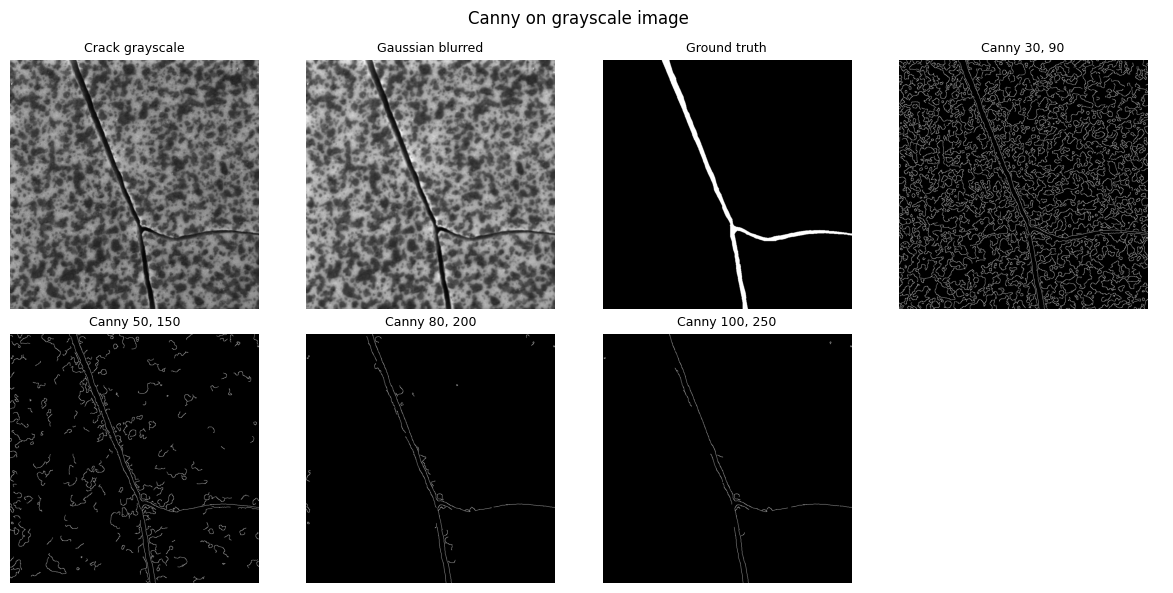

In [10]:
blurred_gray = cv2.GaussianBlur(crack_gray, (5, 5), 0)

canny_params = [(30, 90), (50, 150), (80, 200), (100, 250)]
gray_canny_edges = {}

for low, high in canny_params:
    gray_canny_edges[(low, high)] = cv2.Canny(blurred_gray, low, high)

images = [crack_gray, blurred_gray, gt_binary] + list(gray_canny_edges.values())
titles = ["Crack grayscale", "Gaussian blurred", "Ground truth"] + [
    f"Canny {low}, {high}" for low, high in canny_params
]

show_image_grid(
    images=images,
    titles=titles,
    ncols=4,
    figsize=(12, 6),
    suptitle="Canny on grayscale image",
    cmap_list=["gray"] * len(images)
)

### Observation

Canny on grayscale 符合邊緣檢測原理，但 tile texture 也會產生梯度反應。較高 threshold 能降低背景雜訊，但結果仍是細邊界，不是 crack region。後續若使用 Canny，需要再接 dilation / closing，但它不是本節最穩定的方向。

## Step 6. Morphological Post-processing for Selected Candidates

前面結果顯示，值得進一步嘗試的候選有三個：`Manual T<=50`、`Manual T<=60` 與 `Canny Gray (80, 200)`。本節只驗證這些候選是否能透過簡單 morphology 變成可用的 crack evidence。

In [11]:
def postprocess_manual_threshold_mask(mask: np.ndarray) -> np.ndarray:
    cleaned = remove_small_components(mask, min_area=40)

    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, close_kernel, iterations=1)

    open_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, open_kernel, iterations=1)

    return remove_small_components(opened, min_area=40)


def postprocess_canny_edge_mask(edge_mask: np.ndarray) -> np.ndarray:
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(edge_mask, dilate_kernel, iterations=1)

    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, close_kernel, iterations=1)

    return remove_small_components(closed, min_area=40)


selected_candidates = {
    "Manual T <= 50": manual_threshold_masks[50],
    "Manual T <= 60": manual_threshold_masks[60],
    "Canny Gray (80, 200)": gray_canny_edges[(80, 200)],
}

postprocessed_candidates = {}

for name, candidate_mask in selected_candidates.items():
    if name.startswith("Manual"):
        postprocessed_candidates[name] = postprocess_manual_threshold_mask(candidate_mask)
    else:
        postprocessed_candidates[name] = postprocess_canny_edge_mask(candidate_mask)

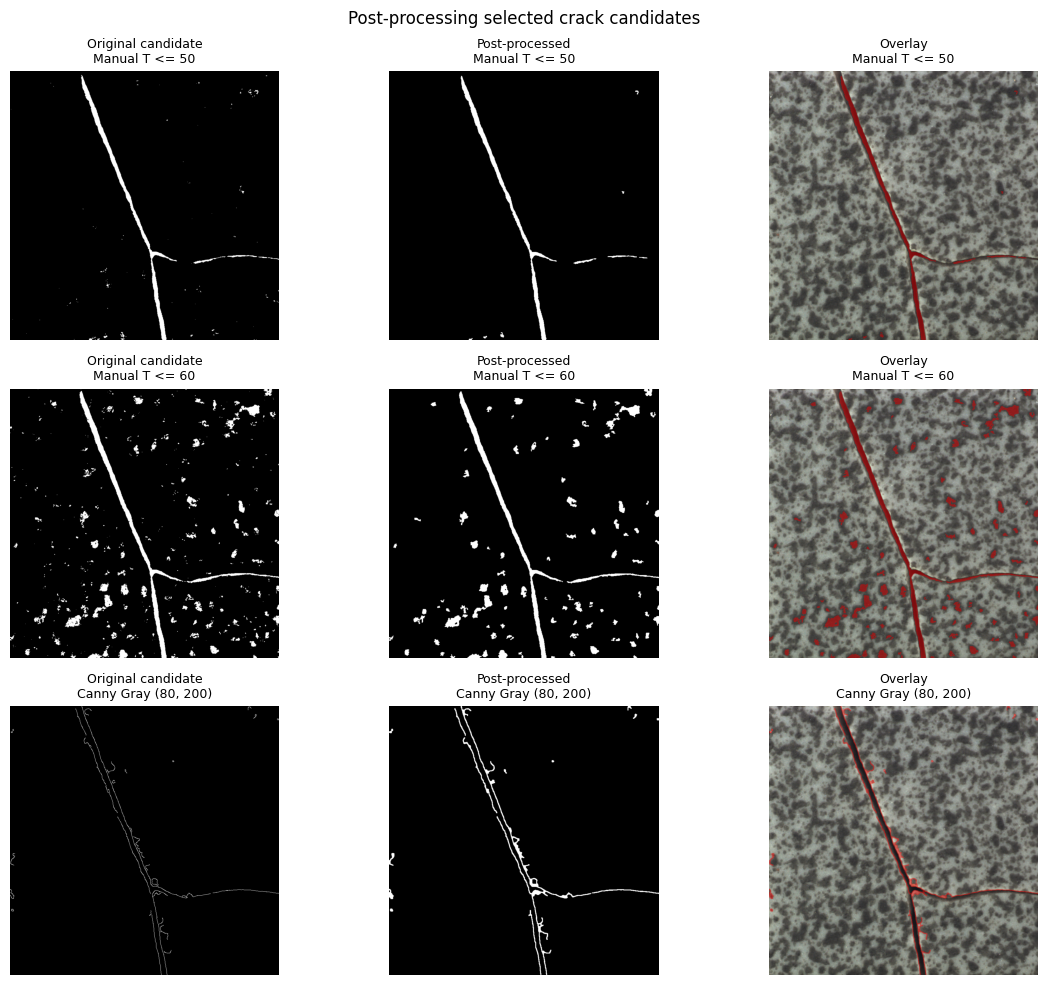

In [12]:
images, titles = [], []

for name, candidate_mask in selected_candidates.items():
    processed_mask = postprocessed_candidates[name]
    overlay = overlay_mask_on_image(crack_rgb, processed_mask)

    images.extend([candidate_mask, processed_mask, overlay])
    titles.extend([
        f"Original candidate\n{name}",
        f"Post-processed\n{name}",
        f"Overlay\n{name}"
    ])

show_image_grid(
    images=images,
    titles=titles,
    ncols=3,
    figsize=(12, 10),
    suptitle="Post-processing selected crack candidates",
    cmap_list=["gray", "gray", None] * len(selected_candidates)
)

### Observation

`Manual T<=50` 背景最少，適合做第一個可解釋 baseline；`Manual T<=60` 雖然保留更多裂縫，但背景雜訊增加；`Canny Gray (80,200)` 能標出裂縫邊界，但仍不是區域 mask。下一節先以 `Manual T<=50` 建立 baseline rule，再測試它是否能泛化到全部 crack samples。

## Step 7. Baseline Rule Test: Manual Threshold + Component Filtering

本節將 `Manual T<=50` 套用到所有 crack images。目的不是宣稱它是最終解法，而是確認固定閾值 baseline 的泛化能力。

In [13]:
BASE_MIN_AREA = 120
BASE_MIN_LONG_SIDE_RATIO = 0.35
BASE_MIN_ASPECT_RATIO = 2.0
BASE_MAX_EXTENT = 0.45


def select_baseline_crack_components(component_records: list[dict]) -> list[dict]:
    selected = []

    for r in component_records:
        if (
            r["area"] >= BASE_MIN_AREA
            and r["long_side_ratio"] >= BASE_MIN_LONG_SIDE_RATIO
            and r["aspect_ratio"] >= BASE_MIN_ASPECT_RATIO
            and r["extent"] <= BASE_MAX_EXTENT
        ):
            selected.append(r)

    return selected


def run_manual_baseline_on_image(image_path: Path, gt_path: Path | None = None) -> dict:
    image_bgr = read_bgr_image(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    _, threshold_mask = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)
    processed_mask = postprocess_manual_threshold_mask(threshold_mask)

    labels, component_records = extract_component_features(processed_mask)
    selected_components = select_baseline_crack_components(component_records)
    component_mask = build_component_mask(labels, selected_components)

    gt_mask = read_gray_image(gt_path) if gt_path is not None and gt_path.exists() else None
    metrics = compute_mask_metrics(component_mask, gt_mask) if gt_mask is not None else {}

    return {
        "image_name": image_path.name,
        "detected": "Yes" if len(selected_components) > 0 else "No",
        "num_components": len(component_records),
        "num_crack_like_components": len(selected_components),
        "image_rgb": image_rgb,
        "gray": gray,
        "processed_mask": processed_mask,
        "component_mask": component_mask,
        "gt_mask": gt_mask,
        **metrics,
    }

In [14]:
crack_image_paths = sorted(CRACK_DIR.glob("*.png"))

manual_baseline_results = []
for image_path in crack_image_paths:
    gt_path = get_gt_path_for_defect(image_path, CRACK_GT_DIR)
    manual_baseline_results.append(run_manual_baseline_on_image(image_path, gt_path))

manual_baseline_df = pd.DataFrame([
    {
        "image_name": r["image_name"],
        "detected": r["detected"],
        "num_components": r["num_components"],
        "num_crack_like_components": r["num_crack_like_components"],
        "iou": round(r.get("iou", 0), 4),
        "precision": round(r.get("precision", 0), 4),
        "recall": round(r.get("recall", 0), 4),
    }
    for r in manual_baseline_results
])

display(manual_baseline_df)

num_images = len(manual_baseline_df)
num_detected = (manual_baseline_df["detected"] == "Yes").sum()

print(f"Total crack images: {num_images}")
print(f"Detected as crack: {num_detected}")
print(f"Missed crack images: {num_images - num_detected}")

,image_name,detected,num_components,num_crack_like_components,iou,precision,recall
0,000.png,Yes,9,1,0.5286,0.9639,0.5393
1,001.png,Yes,18,1,0.2035,0.8047,0.2140
2,002.png,No,1,0,0.0000,0.0000,0.0000
3,003.png,No,11,0,0.0000,0.0000,0.0000
4,004.png,Yes,3,1,0.1661,0.8780,0.1701
5,005.png,No,1,0,0.0000,0.0000,0.0000
6,006.png,No,7,0,0.0000,0.0000,0.0000
7,007.png,Yes,4,1,0.3152,0.9984,0.3153
8,008.png,Yes,11,1,0.1281,1.0000,0.1281
9,009.png,Yes,8,1,0.2746,0.9983,0.2747


Total crack images: 17
Detected as crack: 9
Missed crack images: 8


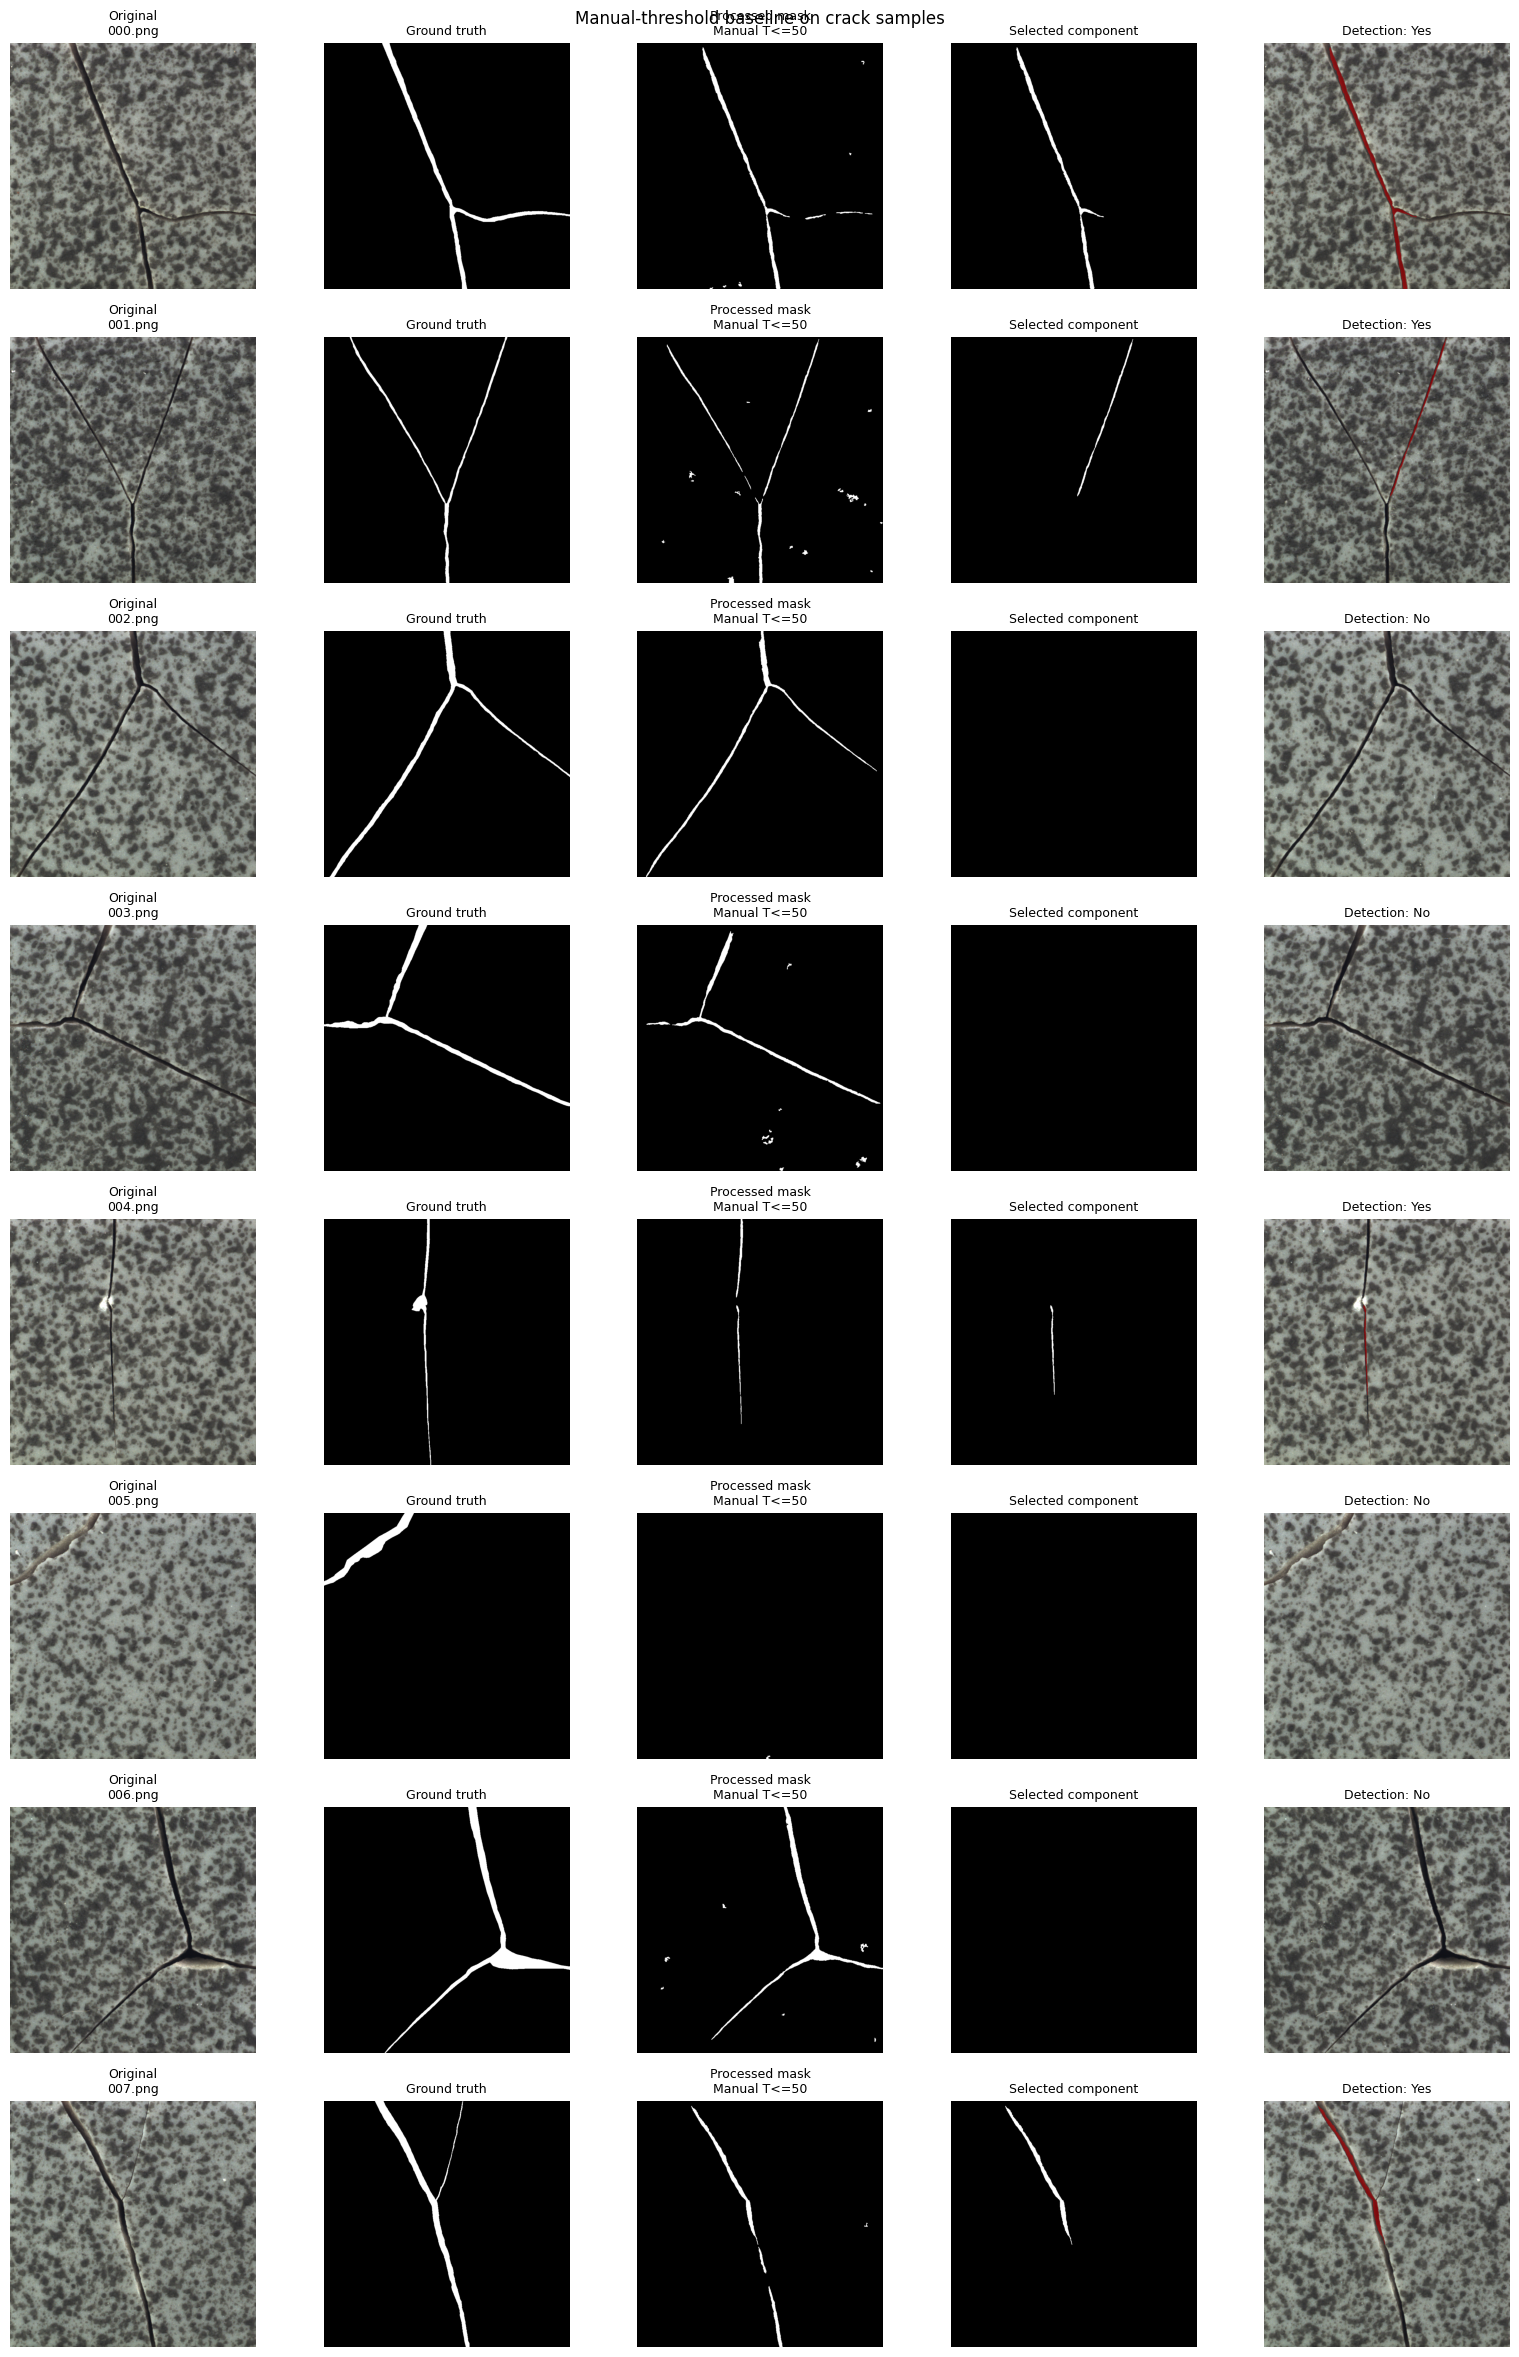

In [15]:
num_show = min(8, len(manual_baseline_results))
images, titles, cmaps = [], [], []

for result in manual_baseline_results[:num_show]:
    overlay = overlay_mask_on_image(result["image_rgb"], result["component_mask"])

    images.extend([
        result["image_rgb"],
        result["gt_mask"],
        result["processed_mask"],
        result["component_mask"],
        overlay,
    ])
    titles.extend([
        f"Original\n{result['image_name']}",
        "Ground truth",
        "Processed mask\nManual T<=50",
        "Selected component",
        f"Detection: {result['detected']}",
    ])
    cmaps.extend([None, "gray", "gray", "gray", None])

show_image_grid(
    images=images,
    titles=titles,
    ncols=5,
    figsize=(16, 3 * num_show),
    suptitle="Manual-threshold baseline on crack samples",
    cmap_list=cmaps
)

### Observation

固定閾值 baseline 的問題是 recall 不足：部分樣本能被準確定位，但不少 crack 在 candidate generation 階段就被漏掉。這表示主要瓶頸不是後面的 component filtering，而是 `gray <= 50` 這種絕對灰階條件無法處理不同深淺與局部對比的 crack。

因此，下一步改用 black-hat morphology，將候選區域生成從「固定灰階值」改成「局部暗色結構增強」。

## Step 8. Black-hat Morphology for Crack Enhancement

Black-hat morphology 的概念是：

```text
black-hat = closing image - original image
```

它會凸顯相對於周圍背景更暗的局部結構，比固定 threshold 更符合 dark crack 的視覺特性。本節將 black-hat 作為最後一個 traditional image processing baseline。

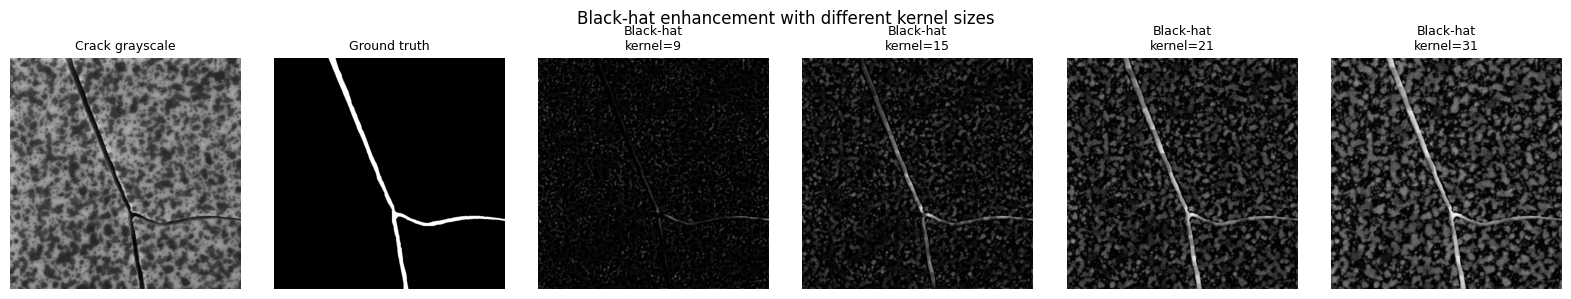

In [16]:
blackhat_kernel_sizes = [9, 15, 21, 31]
blackhat_results = {}

for kernel_size in blackhat_kernel_sizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(crack_gray, cv2.MORPH_BLACKHAT, kernel)
    blackhat_norm = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    blackhat_results[kernel_size] = blackhat_norm

images = [crack_gray, gt_binary] + [blackhat_results[k] for k in blackhat_kernel_sizes]
titles = ["Crack grayscale", "Ground truth"] + [f"Black-hat\nkernel={k}" for k in blackhat_kernel_sizes]

show_image_grid(
    images=images,
    titles=titles,
    ncols=6,
    figsize=(16, 3),
    suptitle="Black-hat enhancement with different kernel sizes",
    cmap_list=["gray"] * len(images)
)

### Observation

Black-hat 能把暗色裂縫從局部背景中凸顯出來。kernel 太小時容易強化細碎紋理；kernel 太大時可能放大較大尺度的背景變化。後續先使用 `kernel=21` 作為折衷設定。

## Step 9. Final Black-hat Detection Rule

本節使用 black-hat response 產生 candidate mask，並以 connected component 規則輸出 `Yes / No`。

這裡保留一個重要踩坑：一開始曾使用 `aspect_ratio` 作為必要條件，但它會錯誤排除 Y-shaped / branching cracks。最終規則移除 aspect ratio，只保留 area、spatial coverage 與 extent。

In [17]:
BLACKHAT_KERNEL_SIZE = 21
BLACKHAT_PERCENTILE = 97
BLACKHAT_MIN_AREA = 40

BH_MIN_AREA = 80
BH_MIN_LONG_SIDE_RATIO = 0.20
BH_MAX_EXTENT = 0.55


def generate_blackhat_candidate_mask(gray_image: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (BLACKHAT_KERNEL_SIZE, BLACKHAT_KERNEL_SIZE)
    )

    blackhat = cv2.morphologyEx(gray_image, cv2.MORPH_BLACKHAT, kernel)
    blackhat_norm = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    threshold_value = np.percentile(blackhat_norm, BLACKHAT_PERCENTILE)
    candidate_mask = (blackhat_norm >= threshold_value).astype(np.uint8) * 255

    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(candidate_mask, cv2.MORPH_CLOSE, close_kernel, iterations=1)
    cleaned = remove_small_components(closed, min_area=BLACKHAT_MIN_AREA)

    return blackhat_norm, candidate_mask, cleaned, threshold_value


def select_final_crack_components(component_records: list[dict]) -> list[dict]:
    selected = []

    for r in component_records:
        # aspect_ratio 不作為必要條件，避免排除分岔型裂縫
        if (
            r["area"] >= BH_MIN_AREA
            and r["long_side_ratio"] >= BH_MIN_LONG_SIDE_RATIO
            and r["extent"] <= BH_MAX_EXTENT
        ):
            selected.append(r)

    return selected


def run_blackhat_detection_on_image(image_path: Path, gt_path: Path | None = None) -> dict:
    image_bgr = read_bgr_image(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    blackhat, candidate_mask, cleaned_mask, threshold_value = generate_blackhat_candidate_mask(gray)

    labels, component_records = extract_component_features(cleaned_mask)
    selected_components = select_final_crack_components(component_records)
    component_mask = build_component_mask(labels, selected_components)

    gt_mask = read_gray_image(gt_path) if gt_path is not None and gt_path.exists() else None
    metrics = compute_mask_metrics(component_mask, gt_mask) if gt_mask is not None else {}

    return {
        "image_name": image_path.name,
        "detected": "Yes" if len(selected_components) > 0 else "No",
        "num_components": len(component_records),
        "num_crack_like_components": len(selected_components),
        "threshold_value": threshold_value,
        "image_rgb": image_rgb,
        "gray": gray,
        "blackhat": blackhat,
        "candidate_mask": candidate_mask,
        "cleaned_mask": cleaned_mask,
        "component_mask": component_mask,
        "gt_mask": gt_mask,
        **metrics,
    }

In [18]:
blackhat_results_all = []

for image_path in crack_image_paths:
    gt_path = get_gt_path_for_defect(image_path, CRACK_GT_DIR)
    blackhat_results_all.append(run_blackhat_detection_on_image(image_path, gt_path))

blackhat_summary_df = pd.DataFrame([
    {
        "image_name": r["image_name"],
        "detected": r["detected"],
        "num_components": r["num_components"],
        "num_crack_like_components": r["num_crack_like_components"],
        "blackhat_threshold": round(r["threshold_value"], 2),
        "iou": round(r.get("iou", 0), 4),
        "precision": round(r.get("precision", 0), 4),
        "recall": round(r.get("recall", 0), 4),
    }
    for r in blackhat_results_all
])

display(blackhat_summary_df)

num_images = len(blackhat_summary_df)
num_detected = (blackhat_summary_df["detected"] == "Yes").sum()

print(f"Total crack images: {num_images}")
print(f"Detected as crack: {num_detected}")
print(f"Missed crack images: {num_images - num_detected}")

,image_name,detected,num_components,num_crack_like_components,blackhat_threshold,iou,precision,recall
0,000.png,Yes,59,1,98.0,0.6087,0.9544,0.6270
1,001.png,Yes,85,2,85.0,0.7674,0.8766,0.8604
2,002.png,Yes,85,1,94.0,0.5854,0.9870,0.5899
3,003.png,Yes,74,1,95.0,0.5839,0.9769,0.5920
4,004.png,Yes,142,1,76.0,0.5762,0.8952,0.6178
5,005.png,No,180,0,130.0,0.0000,0.0000,0.0000
6,006.png,Yes,88,2,91.0,0.4251,0.9739,0.4300
7,007.png,Yes,69,1,106.0,0.7023,0.9927,0.7060
8,008.png,Yes,134,2,100.0,0.3239,0.9526,0.3292
9,009.png,Yes,96,3,90.0,0.5636,0.9682,0.5742


Total crack images: 17
Detected as crack: 16
Missed crack images: 1


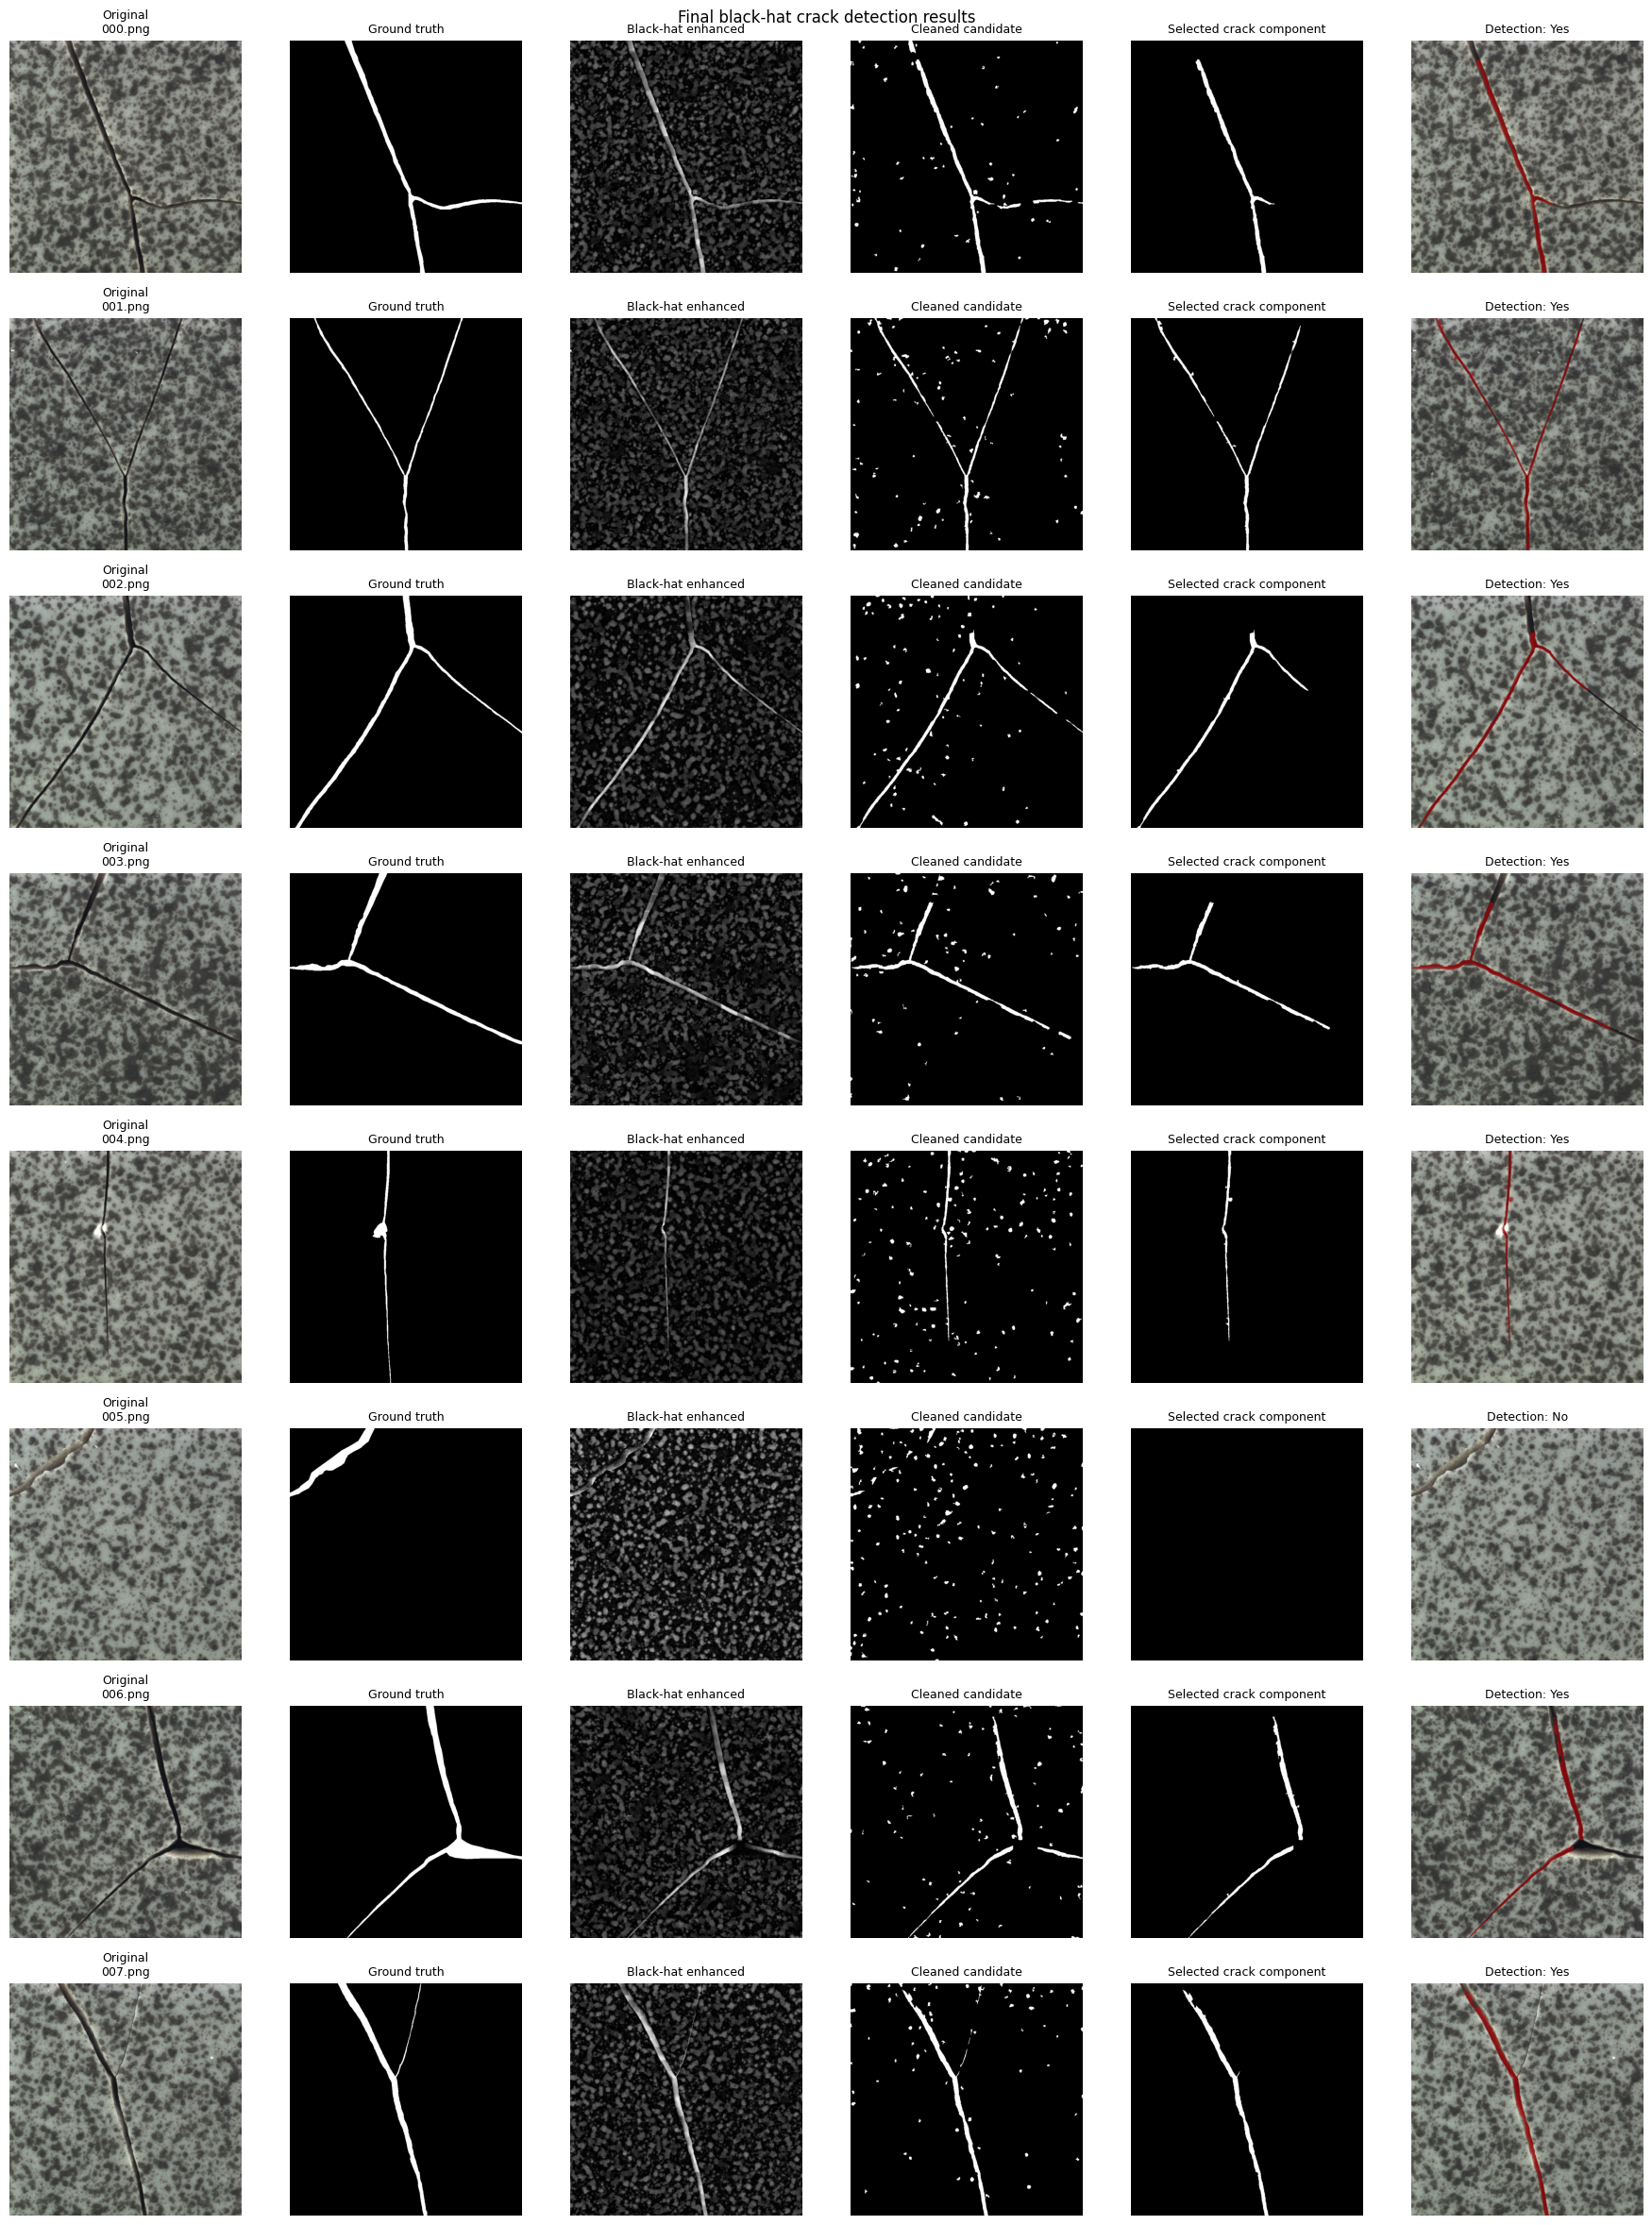

In [19]:
num_show = min(8, len(blackhat_results_all))
images, titles, cmaps = [], [], []

for result in blackhat_results_all[:num_show]:
    overlay = overlay_mask_on_image(result["image_rgb"], result["component_mask"])

    images.extend([
        result["image_rgb"],
        result["gt_mask"],
        result["blackhat"],
        result["cleaned_mask"],
        result["component_mask"],
        overlay,
    ])
    titles.extend([
        f"Original\n{result['image_name']}",
        "Ground truth",
        "Black-hat enhanced",
        "Cleaned candidate",
        "Selected crack component",
        f"Detection: {result['detected']}",
    ])
    cmaps.extend([None, "gray", "gray", "gray", "gray", None])

show_image_grid(
    images=images,
    titles=titles,
    ncols=6,
    figsize=(18, 3 * num_show),
    suptitle="Final black-hat crack detection results",
    cmap_list=cmaps
)

### Observation

移除 aspect ratio 條件後，多數 branching crack 可以被保留下來。這表示前一版失敗的主要原因不是 black-hat 無法強化裂縫，而是 shape filtering 規則過度假設 crack 必須是單一直線。

最終規則不再要求高長寬比，而是判斷 component 是否具有足夠面積、足夠空間延伸，且不是填滿 bounding box 的塊狀紋理。這比單純用 aspect ratio 更適合 Y-shaped 或 multi-directional crack。

若仍有樣本被漏檢，應回到影像特性檢查。以目前觀察到的 `005.png` 為例，其裂縫不是明顯暗色結構，而 black-hat 主要強化「比周圍更暗」的區域，因此該失敗屬於方法假設與樣本特性不一致，而不是單純參數問題。

## Final Summary

本 notebook 最終得到的結論如下：

針對 crack 瑕疵，先嘗試 manual threshold 與 adaptive threshold，並進一步接 Canny edge detection。但 tile 本身具有大量深色斑點紋理，導致基於灰階閾值的方法會同時提取 crack 與背景紋理，因此無法穩定達成 image-level detection 或 localization。

接著直接對灰階影像使用 Canny。雖然這是較標準的 Canny 用法，但因為 tile texture 本身也有大量灰階梯度，Canny 仍會產生許多非 crack 邊緣反應，因此不適合作為主要 pipeline。

最後使用 black-hat morphology。Black-hat 不是依賴固定灰階值，而是強化「相對於周圍背景更暗」的局部結構。這更符合大多數 dark crack 的影像特性，因此能比 threshold / Canny 更穩定地提取 crack candidate。後續再透過 connected component filtering，以 area、spatial coverage 與 extent 篩選 crack-like component，輸出 image-level Yes / No 與 localization mask。

目前唯一明顯漏檢的樣本是 005.png，其裂縫沒有呈現明顯暗色結構，因此不符合 black-hat 的主要假設。這說明 black-hat 適合 dark crack，但對亮色或低暗色對比裂縫仍有限制。